# SVM Smoke Detection Model

This notebook trains and evaluates a Support Vector Machine model for classifying sensor readings as Normal, Cooking, or Fire.

SVM is used because it can find a decision boundary between classes and can work with both simple and non-linear patterns in the sensor data.

#### 1. Imports
Import the libraries needed for data loading, scaling, model training, tuning, and evaluation.

In [14]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


#### 2. Settings
Define the data file, selected features, class names, and random state.

In [15]:
NOTEBOOK_DIR = Path('.').resolve()
DATA_DIR     = NOTEBOOK_DIR

FEATURES    = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
CLASS_NAMES = ['Normal', 'Cooking', 'Fire']
RS          = 42


#### 3. Load Prepared Data
Load the final merged dataset and check the class distribution.

In [16]:
df = pd.read_excel(DATA_DIR / 'merged_dataset.xlsx')

print('Shape:', df.shape)
print('Class distribution:')
for name in CLASS_NAMES:
    n = (df['label'] == name).sum()
    print(f'  {name:8s}: {n:6d} ({n/len(df)*100:.1f}%)')

display(df.head())


Shape: (60212, 6)
Class distribution:
  Normal  :  14671 (24.4%)
  Cooking :   4718 (7.8%)
  Fire    :  40823 (67.8%)


,temperature,humidity,tvoc_ppb,eco2_ppm,label,class_id
0,23.4,44.0,27,408,Normal,0
1,23.4,44.0,30,414,Normal,0
2,23.4,44.0,28,410,Normal,0
3,23.4,44.0,29,413,Normal,0
4,23.4,44.0,31,417,Normal,0


#### 4. Feature Distributions
Plot the feature distributions to see how sensor readings differ between classes.

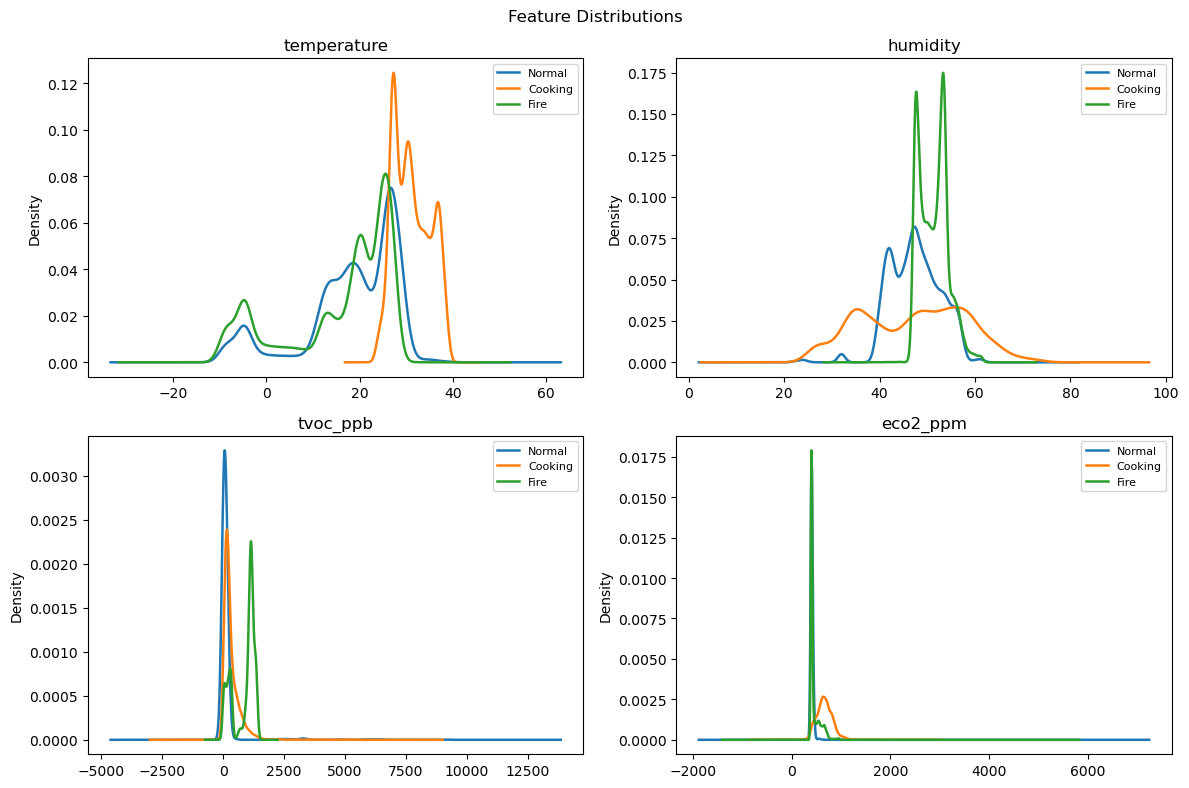

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions')

for ax, feature in zip(axes.flat, FEATURES):
    for class_id, class_name in enumerate(CLASS_NAMES):
        values = df[df['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=class_name, linewidth=1.8)

    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


#### 5. Train, Validation, and Test Split
Split the data into 70% training, 15% validation, and 15% test. The test set is kept locked until the final evaluation.

In [19]:
feature_cols = df[FEATURES]
target_col = df['class_id']

X_train, X_remaining, y_train, y_remaining = train_test_split(
    feature_cols,
    target_col,
    test_size=0.30,
    random_state=RS,
    stratify=target_col
)

X_val, X_test, y_val, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.50,
    random_state=RS,
    stratify=y_remaining
)

print('Full dataset:', df.shape, '\n')
print('Data split summary:')
print('Training set  :', X_train.shape)
print('Validation set:', X_val.shape)
print('Test set      :', X_test.shape)

split_summary = pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'validation': y_val.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True),
}).fillna(0).round(3)

split_summary.index = [CLASS_NAMES[class_id] for class_id in split_summary.index]
display(split_summary)


Full dataset: (60212, 6) 

Data split summary:
Training set  : (42148, 4)
Validation set: (9032, 4)
Test set      : (9032, 4)


,train,validation,test
Fire,0.678,0.678,0.678
Normal,0.244,0.244,0.244
Cooking,0.078,0.078,0.078


#### 6. Scale Features
Fit the scaler on the training data only, then apply the same transformation to validation and test data.

In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaler fitted on train only.')
print('Means:', dict(zip(FEATURES, scaler.mean_.round(2))))
print('Stds :', dict(zip(FEATURES, scaler.scale_.round(2))))


Scaler fitted on train only.
Means: {'temperature': 17.7, 'humidity': 50.08, 'tvoc_ppb': 652.3, 'eco2_ppm': 464.5}
Stds : {'temperature': 11.52, 'humidity': 5.09, 'tvoc_ppb': 594.78, 'eco2_ppm': 142.23}


#### 7. Baseline SVM
Train a first SVM model before tuning, then evaluate it on the validation set.

Validation set - baseline SVM
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91      2200
     Cooking       0.99      0.96      0.98       708
        Fire       1.00      0.94      0.97      6124

    accuracy                           0.95      9032
   macro avg       0.94      0.96      0.95      9032
weighted avg       0.96      0.95      0.95      9032



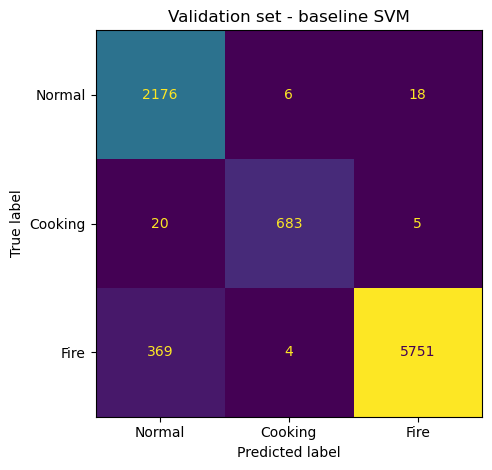

In [7]:
svm_base = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=RS
)

svm_base.fit(X_train_sc, y_train)

y_val_pred = svm_base.predict(X_val_sc)

print('Validation set - baseline SVM')
print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES, labels=[0, 1, 2], zero_division=0))

baseline_validation_confusion_matrix = confusion_matrix(y_val, y_val_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(baseline_validation_confusion_matrix, display_labels=CLASS_NAMES).plot(colorbar=False)
plt.title('Validation set - baseline SVM')
plt.tight_layout()
plt.show()


#### 8. Tune SVM
Tune a small set of SVM settings using a stratified sample of the training data. The best settings are then used for the final model.

In [21]:
random_generator = np.random.RandomState(RS)
sampled_train_indices = np.concatenate([
    random_generator.choice(
        np.where(y_train == class_id)[0],
        min(len(np.where(y_train == class_id)[0]), int(6000 * len(np.where(y_train == class_id)[0]) / len(y_train))),
        replace=False
    )
    for class_id in [0, 1, 2]
])

X_tuning_sample = X_train_sc[sampled_train_indices]
y_tuning_sample = y_train.iloc[sampled_train_indices]
print(f'Tuning sample: {len(y_tuning_sample)} rows')

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1.0],
    'gamma': ['scale'],
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RS)
grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=RS),
    param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tuning_sample, y_tuning_sample)

print('Best params      :', grid_search.best_params_)
print('Best CV F1-macro:', round(grid_search.best_score_, 4))


Tuning sample: 5998 rows
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params      : {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-macro: 0.9369


#### 9. Train Tuned SVM
Retrain the best SVM configuration on the full training set.

In [22]:
svm_best = SVC(
    **grid_search.best_params_,
    class_weight='balanced',
    random_state=RS
)

svm_best.fit(X_train_sc, y_train)


SVC(class_weight='balanced', random_state=42)

#### 10. Validation Evaluation
Evaluate the tuned model on the validation set before using the final test set.

Validation set - tuned SVM
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91      2200
     Cooking       0.99      0.96      0.98       708
        Fire       1.00      0.94      0.97      6124

    accuracy                           0.95      9032
   macro avg       0.94      0.96      0.95      9032
weighted avg       0.96      0.95      0.95      9032



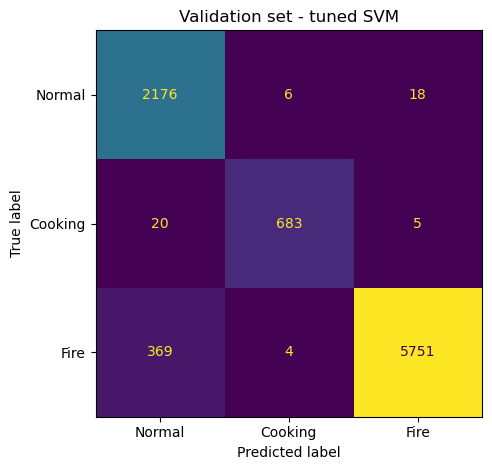

In [24]:
y_val_pred_tuned = svm_best.predict(X_val_sc)

print('Validation set - tuned SVM')
print(classification_report(y_val, y_val_pred_tuned, target_names=CLASS_NAMES, labels=[0, 1, 2], zero_division=0))

tuned_validation_confusion_matrix = confusion_matrix(y_val, y_val_pred_tuned, labels=[0, 1, 2])
ConfusionMatrixDisplay(tuned_validation_confusion_matrix, display_labels=CLASS_NAMES).plot(colorbar=False)
plt.title('Validation set - tuned SVM')
plt.tight_layout()
plt.show()


#### 11. Final Test Evaluation
Evaluate the final model on the locked test set only once.

Test set - final SVM
              precision    recall  f1-score   support

      Normal       0.84      0.99      0.91      2201
     Cooking       0.99      0.98      0.98       708
        Fire       1.00      0.94      0.96      6123

    accuracy                           0.95      9032
   macro avg       0.94      0.97      0.95      9032
weighted avg       0.96      0.95      0.95      9032



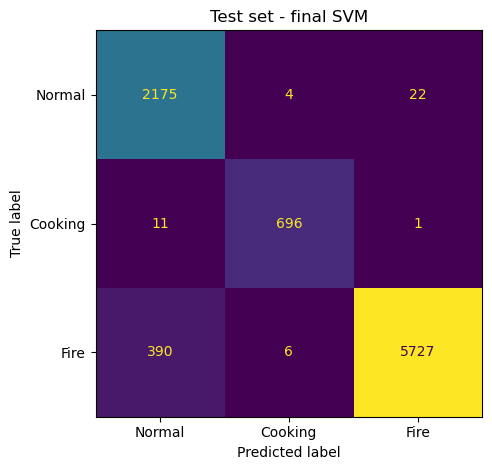

In [25]:
y_test_pred = svm_best.predict(X_test_sc)

print('Test set - final SVM')
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, labels=[0, 1, 2], zero_division=0))

final_test_confusion_matrix = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
ConfusionMatrixDisplay(final_test_confusion_matrix, display_labels=CLASS_NAMES).plot(colorbar=False)
plt.title('Test set - final SVM')
plt.tight_layout()
plt.show()


#### 12. Confusion Matrix Comparison
Compare validation and test confusion matrices side by side.

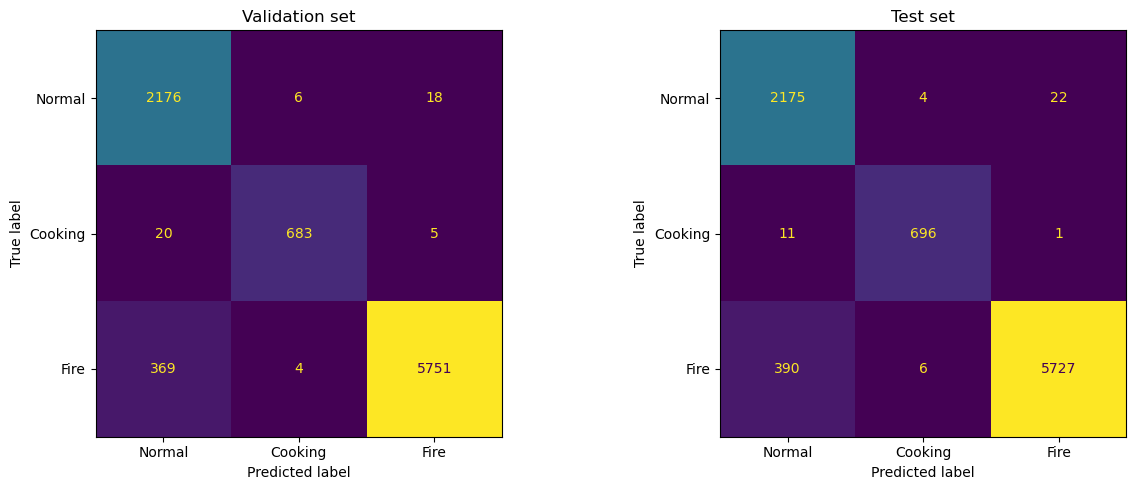

Cooking -> Fire errors in test: 1


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val, y_val_pred_tuned, 'Validation set'),
    (axes[1], y_test, y_test_pred, 'Test set'),
]:
    current_confusion_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    ConfusionMatrixDisplay(current_confusion_matrix, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Cooking -> Fire errors in test:', confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])[1][2])


#### 13. Recall and Overfitting Check
Check class recall and compare training, validation, and test F1-scores.

In [27]:
train_pred = svm_best.predict(X_train_sc)

train_f1 = f1_score(y_train, train_pred, average='macro')
val_f1   = f1_score(y_val, y_val_pred_tuned, average='macro')
test_f1  = f1_score(y_test, y_test_pred, average='macro')

print(f'Train F1-macro: {train_f1:.4f}')
print(f'Val F1-macro  : {val_f1:.4f}')
print(f'Test F1-macro : {test_f1:.4f}')
print(f'Train-Val gap : {train_f1 - val_f1:.4f}')

recalls = recall_score(y_test, y_test_pred, labels=[0, 1, 2], average=None, zero_division=0)
print('\nTest recall per class:')
for name, score in zip(CLASS_NAMES, recalls):
    print(f'  {name:8s}: {score:.4f}')
print('Macro recall:', recall_score(y_test, y_test_pred, average='macro', zero_division=0).round(4))


Train F1-macro: 0.9544
Val F1-macro  : 0.9517
Test F1-macro : 0.9533
Train-Val gap : 0.0027

Test recall per class:
  Normal  : 0.9882
  Cooking : 0.9831
  Fire    : 0.9353
Macro recall: 0.9689


#### 14. Save Model
Save the final tuned model and scaler for later use.

In [28]:
joblib.dump(svm_best, NOTEBOOK_DIR / 'model_svm.joblib')
joblib.dump(scaler,   NOTEBOOK_DIR / 'scaler_svm.joblib')

print('Saved model_svm.joblib')
print('Saved scaler_svm.joblib')
print('Best params:', grid_search.best_params_)


Saved model_svm.joblib
Saved scaler_svm.joblib
Best params: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}


#### 15. Final Notes

The final SVM model uses the merged dataset, scaled features, tuned settings, and a locked test set for final evaluation.

The most important results are the macro F1-score, per-class recall, and the confusion matrix, especially mistakes between Cooking and Fire.